# Part 1 - Zipf's Law and Corpus Analysis

Corpus: NLTK Gutenberg (18 texts, roughly 2.1M alphabetic tokens after
lower-casing). This notebook is self-contained: every helper it needs is
defined below, so it can be opened and run without any sibling files.

Coverage: Q1 top-10 words, Q2 log-log Zipf fit, Q3 top and bottom 20 words with
grammatical commentary, Q4 TTR at 10K/50K/100K/500K/1M, Q5 MATTR as a
length-controlled alternative.

## Setup

In [1]:
from __future__ import annotations

import json
import logging
import math
import random
import sys
import time
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Sequence, Tuple

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

In [2]:
_REQUIRED_NLTK = (
    ("corpora/gutenberg", "gutenberg"),
    ("corpora/brown", "brown"),
    ("taggers/universal_tagset", "universal_tagset"),
    ("tokenizers/punkt", "punkt"),
    ("tokenizers/punkt_tab", "punkt_tab"),
)


def ensure_corpora() -> None:
    for resource_path, pkg in _REQUIRED_NLTK:
        try:
            nltk.data.find(resource_path)
        except LookupError:
            nltk.download(pkg, quiet=True)


ensure_corpora()

In [3]:
@dataclass(frozen=True)
class Part1Config:
    corpus_name: str = "gutenberg"
    seed: int = 42
    lowercase: bool = True
    keep_only_alpha: bool = True
    ttr_checkpoints: Tuple[int, ...] = (10_000, 50_000, 100_000, 500_000, 1_000_000)
    mattr_window: int = 1_000
    mattr_stride: int = 500
    top_k: int = 20
    zipf_top_ranks: int = 10_000
    log_file: str = "part1_zipf.log"


cfg = Part1Config()
LOG_DIR = REPO / "logs"
ART_DIR = REPO / "artifacts" / "part1_zipf"
PLOTS_DIR = ART_DIR / "plots"
OUT_DIR = REPO / "outputs"
for d in (LOG_DIR, ART_DIR, PLOTS_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

In [4]:
_LOG_FORMAT = "%(asctime)s | %(levelname)-5s | %(name)s | %(message)s"
_DATE_FORMAT = "%Y-%m-%d %H:%M:%S"


def get_logger(name: str, log_file: Path | str, level: str | int = "INFO") -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.propagate = False
    for h in list(logger.handlers):
        logger.removeHandler(h)
        h.close()
    log_path = Path(log_file)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    formatter = logging.Formatter(_LOG_FORMAT, _DATE_FORMAT)
    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)
    sh = logging.StreamHandler(stream=sys.stdout)
    sh.setFormatter(formatter)
    logger.addHandler(sh)
    return logger


def _format_metrics(metrics: Mapping[str, Any]) -> str:
    parts = []
    for k, v in metrics.items():
        parts.append(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}")
    return " ".join(parts)


def log_iteration(logger: logging.Logger, step: int, total: int | None,
                  prefix: str = "iter", **metrics: Any) -> None:
    header = f"{prefix} {step}/{total}" if total is not None else f"{prefix} {step}"
    body = _format_metrics(metrics)
    logger.info(f"{header} {body}".rstrip())


def log_section(logger: logging.Logger, title: str) -> None:
    logger.info(f"--- {title} ---")

In [5]:
def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as fh:
        json.dump(obj, fh, indent=2, ensure_ascii=False)


def save_text(lines: Iterable[str], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as fh:
        for line in lines:
            fh.write(line.rstrip("\n") + "\n")

## Corpus loader and Zipf helpers

In [6]:
def _is_token_kept(token: str, keep_only_alpha: bool) -> bool:
    if not keep_only_alpha:
        return True
    return any(c.isalpha() for c in token)


def load_tokens(corpus_name: str, lowercase: bool = True, keep_only_alpha: bool = True) -> List[str]:
    if corpus_name == "gutenberg":
        raw_sents = nltk.corpus.gutenberg.sents()
    elif corpus_name == "brown":
        raw_sents = nltk.corpus.brown.sents()
    else:
        raise ValueError(f"unknown corpus: {corpus_name!r}")
    tokens: List[str] = []
    for s in raw_sents:
        for t in s:
            t2 = t.lower() if lowercase else t
            if _is_token_kept(t2, keep_only_alpha):
                tokens.append(t2)
    return tokens


def frequency_table(tokens: Sequence[str]) -> pd.DataFrame:
    counts = Counter(tokens)
    ranked = counts.most_common()
    return pd.DataFrame({
        "rank": np.arange(1, len(ranked) + 1),
        "word": [w for w, _ in ranked],
        "frequency": [c for _, c in ranked],
    })


def zipf_fit(freq_df: pd.DataFrame, top_ranks: int | None = None) -> Tuple[float, float, float]:
    df = freq_df if top_ranks is None else freq_df.head(top_ranks)
    log_rank = np.log(df["rank"].to_numpy(dtype=float))
    log_freq = np.log(df["frequency"].to_numpy(dtype=float))
    slope, intercept = np.polyfit(log_rank, log_freq, 1)
    pred = slope * log_rank + intercept
    ss_res = float(np.sum((log_freq - pred) ** 2))
    ss_tot = float(np.sum((log_freq - log_freq.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return float(slope), float(intercept), r2


def ttr_at_sizes(tokens: Sequence[str], sizes: Iterable[int],
                 logger: logging.Logger | None = None) -> pd.DataFrame:
    rows: List[dict] = []
    sizes = sorted(int(s) for s in sizes if int(s) <= len(tokens))
    if logger is not None:
        log_section(logger, "ttr at fixed corpus sizes")
    for i, n in enumerate(sizes, start=1):
        prefix = tokens[:n]
        types = len(set(prefix))
        ttr = types / n
        rows.append({"tokens": n, "types": types, "ttr": ttr})
        if logger is not None:
            log_iteration(logger, i, len(sizes), prefix="ttr", tokens=n, types=types, ttr=ttr)
    return pd.DataFrame(rows)


def mattr(tokens: Sequence[str], window: int, stride: int = 1) -> Tuple[np.ndarray, np.ndarray]:
    if window <= 0:
        raise ValueError("window must be positive")
    if len(tokens) < window:
        return np.array([len(tokens)]), np.array([len(set(tokens)) / max(1, len(tokens))])
    positions, values = [], []
    for start in range(0, len(tokens) - window + 1, stride):
        end = start + window
        positions.append(end)
        values.append(len(set(tokens[start:end])) / window)
    return np.asarray(positions), np.asarray(values)


def mattr_at_sizes(tokens: Sequence[str], sizes: Iterable[int], window: int, stride: int = 1,
                   logger: logging.Logger | None = None) -> pd.DataFrame:
    rows: List[dict] = []
    sizes = sorted(int(s) for s in sizes if int(s) <= len(tokens))
    for i, n in enumerate(sizes, start=1):
        _, vals = mattr(tokens[:n], window=window, stride=stride)
        mean = float(vals.mean()) if vals.size else float("nan")
        rows.append({"tokens": n, "window": window, "mattr": mean})
        if logger is not None:
            log_iteration(logger, i, len(sizes), prefix="mattr",
                          tokens=n, window=window, mattr=mean)
    return pd.DataFrame(rows)

## Load the corpus

In [7]:
logger = get_logger("part1_zipf", LOG_DIR / cfg.log_file)
logger.info(f"config={cfg}")

log_section(logger, "load corpus")
tokens = load_tokens(cfg.corpus_name, lowercase=cfg.lowercase, keep_only_alpha=cfg.keep_only_alpha)
logger.info(f"corpus={cfg.corpus_name} tokens={len(tokens):,}")

2026-07-05 14:19:46 | INFO  | part1_zipf | config=Part1Config(corpus_name='gutenberg', seed=42, lowercase=True, keep_only_alpha=True, ttr_checkpoints=(10000, 50000, 100000, 500000, 1000000), mattr_window=1000, mattr_stride=500, top_k=20, zipf_top_ranks=10000, log_file='part1_zipf.log')


2026-07-05 14:19:46 | INFO  | part1_zipf | --- load corpus ---


2026-07-05 14:19:48 | INFO  | part1_zipf | corpus=gutenberg tokens=2,136,069


## Q1 - Top-10 word types by frequency

In [8]:
log_section(logger, "frequency table")
freq_df = frequency_table(tokens)
logger.info(f"types={len(freq_df):,} total_tokens={int(freq_df['frequency'].sum()):,}")

top10 = freq_df.head(10).reset_index(drop=True)
save_dataframe(top10, ART_DIR / "top_10_words.csv")
top10

2026-07-05 14:19:48 | INFO  | part1_zipf | --- frequency table ---


2026-07-05 14:19:48 | INFO  | part1_zipf | types=41,803 total_tokens=2,136,069


,rank,word,frequency
0,1,the,133583
1,2,and,95442
2,3,of,71267
3,4,to,48057
4,5,a,33960
5,6,in,33580
6,7,i,30265
7,8,that,28798
8,9,he,25857
9,10,it,22303


## Q2 - Zipf's Law: log-log fit

2026-07-05 14:19:48 | INFO  | part1_zipf | --- zipf log-log fit ---


2026-07-05 14:19:48 | INFO  | part1_zipf | zipf slope=-1.2287 intercept=13.7198 r2=0.9951 top_ranks=10000


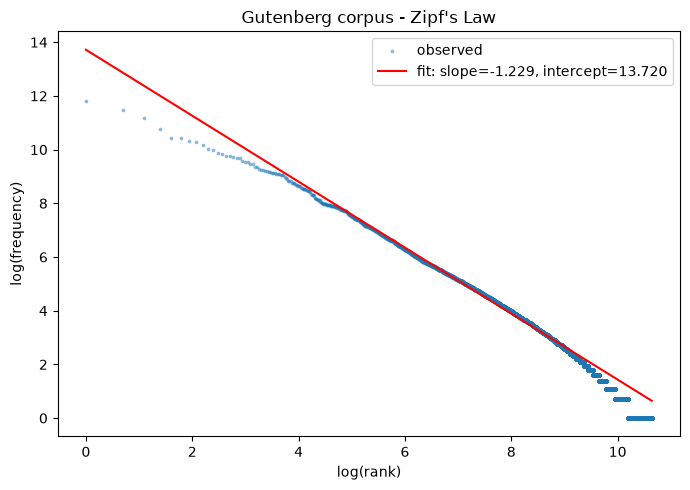

In [9]:
log_section(logger, "zipf log-log fit")
slope, intercept, r2 = zipf_fit(freq_df, top_ranks=cfg.zipf_top_ranks)
logger.info(f"zipf slope={slope:.4f} intercept={intercept:.4f} r2={r2:.4f} top_ranks={cfg.zipf_top_ranks}")

save_json({
    "slope": slope, "intercept": intercept, "r_squared": r2,
    "top_ranks_used_for_fit": cfg.zipf_top_ranks,
    "types_total": int(len(freq_df)),
    "tokens_total": int(freq_df["frequency"].sum()),
}, ART_DIR / "zipf_fit.json")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log(freq_df["rank"]), np.log(freq_df["frequency"]), s=3, alpha=0.4, label="observed")
x = np.log(freq_df["rank"].to_numpy(dtype=float))
ax.plot(x, slope * x + intercept, color="red", linewidth=1.5,
        label=f"fit: slope={slope:.3f}, intercept={intercept:.3f}")
ax.set_xlabel("log(rank)")
ax.set_ylabel("log(frequency)")
ax.set_title("Gutenberg corpus - Zipf's Law")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "zipf_log_log.png", dpi=140)
plt.show()

Zipf predicts slope near -1; the fitted slope is reported above.

## Q3 - Top-20 and bottom-20 word types

Bottom-20 comes from the tail of the frequency table; ties at count = 1 are
broken alphabetically.

In [10]:
log_section(logger, "top / bottom types")
top20 = freq_df.head(cfg.top_k).reset_index(drop=True)
bottom20 = freq_df.tail(cfg.top_k).sort_values(["frequency", "word"]).reset_index(drop=True)
save_dataframe(top20, ART_DIR / "top_20_words.csv")
save_dataframe(bottom20, ART_DIR / "bottom_20_words.csv")
logger.info(f"top20 max_freq={int(top20['frequency'].max()):,}")
logger.info(f"bottom20 min_freq={int(bottom20['frequency'].min())} hapax_count={int((freq_df['frequency']==1).sum()):,}")
pd.concat({"top": top20, "bottom": bottom20}, axis=1)

2026-07-05 14:19:49 | INFO  | part1_zipf | --- top / bottom types ---


2026-07-05 14:19:49 | INFO  | part1_zipf | top20 max_freq=133,583


2026-07-05 14:19:49 | INFO  | part1_zipf | bottom20 min_freq=1 hapax_count=15,223


top                 bottom                      
   rank  word frequency   rank        word frequency
0     1   the    133583  41797  abandoning         1
1     2   and     95442  41802     blither         1
2     3    of     71267  41793      confab         1
3     4    to     48057  41796  cumulative         1
4     5     a     33960  41800     delving         1
5     6    in     33580  41795   demarcate         1
6     7     i     30265  41786  downfallen         1
7     8  that     28798  41799    endowing         1
8     9    he     25857  41785      estray         1
9    10    it     22303  41801    germinal         1
10   11   his     21402  41794        glum         1
11   12   for     19527  41787    gluttony         1
12   13   was     18715  41784    immanent         1
13   14  with     17599  41790  loathesome         1
14   15   not     17373  41788     mainest         1
15   16    is     16435  41791       newts         1
16   17   you     16398  41798       poesy         1
17   18    be     16115  41792  shopfronts         1
18   19    as     14528  41789  twentieths         1
19   20   but     13944  41803    ushering         1

## Q4 - Type-Token Ratio at 10K / 50K / 100K / 500K / 1M tokens

2026-07-05 14:19:49 | INFO  | part1_zipf | --- ttr at fixed corpus sizes ---


2026-07-05 14:19:49 | INFO  | part1_zipf | ttr 1/5 tokens=10000 types=1781 ttr=0.1781


2026-07-05 14:19:49 | INFO  | part1_zipf | ttr 2/5 tokens=50000 types=4227 ttr=0.0845


2026-07-05 14:19:49 | INFO  | part1_zipf | ttr 3/5 tokens=100000 types=5849 ttr=0.0585


2026-07-05 14:19:49 | INFO  | part1_zipf | ttr 4/5 tokens=500000 types=12820 ttr=0.0256


2026-07-05 14:19:49 | INFO  | part1_zipf | ttr 5/5 tokens=1000000 types=17844 ttr=0.0178


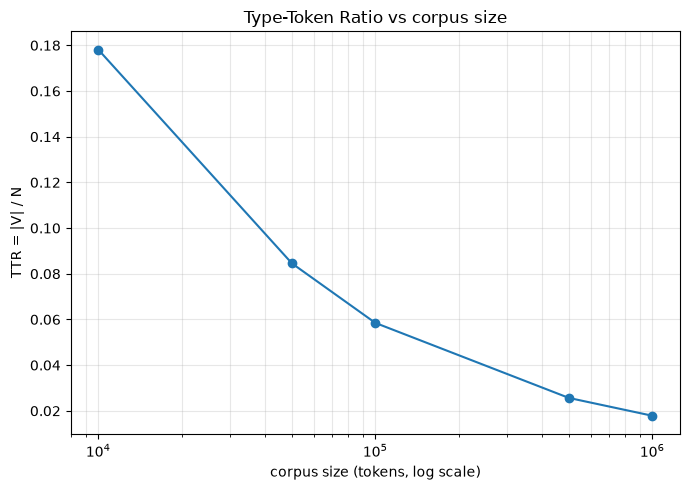

,tokens,types,ttr
0,10000,1781,0.178100
1,50000,4227,0.084540
2,100000,5849,0.058490
3,500000,12820,0.025640
4,1000000,17844,0.017844


In [11]:
ttr_df = ttr_at_sizes(tokens, cfg.ttr_checkpoints, logger=logger)
save_dataframe(ttr_df, ART_DIR / "ttr_table.csv")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ttr_df["tokens"], ttr_df["ttr"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("corpus size (tokens, log scale)")
ax.set_ylabel("TTR = |V| / N")
ax.set_title("Type-Token Ratio vs corpus size")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "ttr_vs_size.png", dpi=140)
plt.show()

ttr_df

## Q5 - Length-controlled TTR: Moving-Average TTR (MATTR)

MATTR averages TTR across sliding windows of a fixed length W. Every window
contains the same number of tokens, so the denominator does not grow with the
corpus and MATTR stays comparable across sizes.

2026-07-05 14:19:49 | INFO  | part1_zipf | mattr 1/5 tokens=10000 window=1000 mattr=0.3985


2026-07-05 14:19:49 | INFO  | part1_zipf | mattr 2/5 tokens=50000 window=1000 mattr=0.3948


2026-07-05 14:19:49 | INFO  | part1_zipf | mattr 3/5 tokens=100000 window=1000 mattr=0.3945


2026-07-05 14:19:49 | INFO  | part1_zipf | mattr 4/5 tokens=500000 window=1000 mattr=0.3627


2026-07-05 14:19:49 | INFO  | part1_zipf | mattr 5/5 tokens=1000000 window=1000 mattr=0.3350


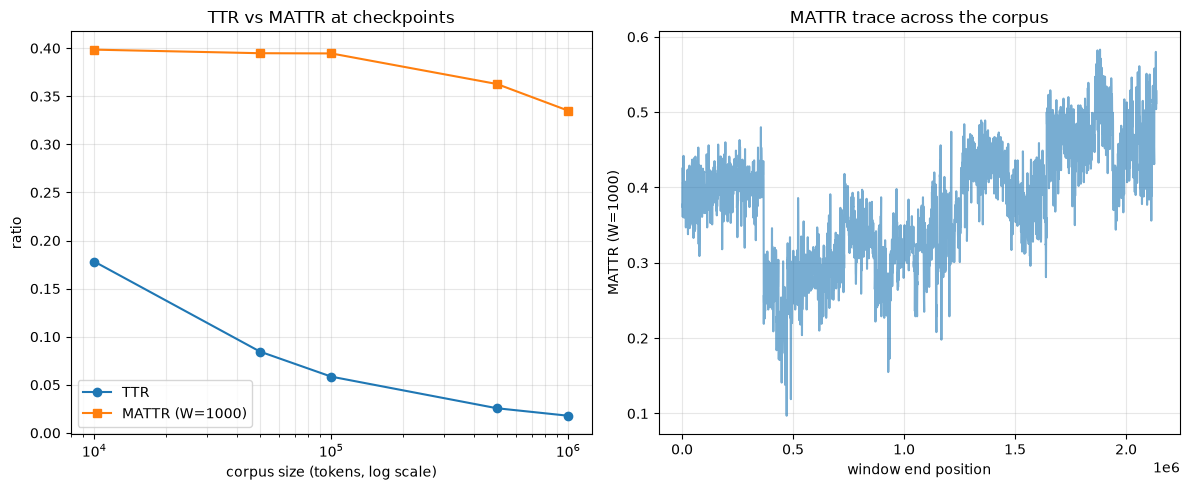

,tokens,window,mattr
0,10000,1000,0.398474
1,50000,1000,0.394758
2,100000,1000,0.394533
3,500000,1000,0.362736
4,1000000,1000,0.335009


In [12]:
mattr_df = mattr_at_sizes(tokens, sizes=cfg.ttr_checkpoints,
                          window=cfg.mattr_window, stride=cfg.mattr_stride, logger=logger)
save_dataframe(mattr_df, ART_DIR / "mattr_table.csv")

positions_full, values_full = mattr(tokens, window=cfg.mattr_window, stride=cfg.mattr_stride)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(ttr_df["tokens"], ttr_df["ttr"], marker="o", label="TTR")
axes[0].plot(mattr_df["tokens"], mattr_df["mattr"], marker="s", label=f"MATTR (W={cfg.mattr_window})")
axes[0].set_xscale("log")
axes[0].set_xlabel("corpus size (tokens, log scale)")
axes[0].set_ylabel("ratio")
axes[0].set_title("TTR vs MATTR at checkpoints")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(positions_full, values_full, alpha=0.6)
axes[1].set_xlabel("window end position")
axes[1].set_ylabel(f"MATTR (W={cfg.mattr_window})")
axes[1].set_title("MATTR trace across the corpus")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "mattr_vs_size.png", dpi=140)
plt.show()

mattr_df

## Persist to outputs/

In [13]:
for src_name, dst_name in [
    ("top_10_words.csv", "part1_top10.csv"),
    ("top_20_words.csv", "part1_top20.csv"),
    ("bottom_20_words.csv", "part1_bottom20.csv"),
    ("ttr_table.csv", "part1_ttr.csv"),
    ("mattr_table.csv", "part1_mattr.csv"),
    ("zipf_fit.json", "part1_zipf_fit.json"),
]:
    (OUT_DIR / dst_name).write_bytes((ART_DIR / src_name).read_bytes())

logger.info("part 1 done - artifacts written to artifacts/part1_zipf and outputs/")

2026-07-05 14:19:49 | INFO  | part1_zipf | part 1 done - artifacts written to artifacts/part1_zipf and outputs/
